In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
df = pd.read_csv('Clean_Dataset.csv')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


 | Variable         | Type                                     |
| ---------------- | ----------------------------------------- |
| price            | Continue                                  |
| duration         | Continue                                  |
| days_left        | Continue                                  |
| stops            | Discrète                                  |
| airline          | Catégorielle nominale                     |
| flight           | Catégorielle nominale                     |
| source_city      | Catégorielle nominale                     |
| destination_city | Catégorielle nominale                     |
| class            | Catégorielle nominale                     |
| departure_time   | Ordinale                                  |
| arrival_time     | Ordinale                                  |


In [23]:
df['airline'] = df['airline'].astype('category')
df['source_city'] = df['source_city'].astype('category')
df['departure_time'] = df['departure_time'].astype('category')
df['stops'] = df['stops'].astype('category')
df['arrival_time'] = df['arrival_time'].astype('category')
df['destination_city'] = df['destination_city'].astype('category')
df['class'] = df['class'].astype('category')

In [24]:
df = df.drop(columns= 'Unnamed: 0')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   airline           300153 non-null  category
 1   flight            300153 non-null  object  
 2   source_city       300153 non-null  category
 3   departure_time    300153 non-null  category
 4   stops             300153 non-null  category
 5   arrival_time      300153 non-null  category
 6   destination_city  300153 non-null  category
 7   class             300153 non-null  category
 8   duration          300153 non-null  float64 
 9   days_left         300153 non-null  int64   
 10  price             300153 non-null  int64   
dtypes: category(7), float64(1), int64(2), object(1)
memory usage: 11.2+ MB


In [26]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

# LES TYPES DE VARIABLES

#### durée du vol vs prix


C:\Users\Abdelilah\AppData\Local\Temp\ipykernel_18116\764659006.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("duration_bin")["price"].mean()


<Axes: xlabel='duration_bin', ylabel='price'>

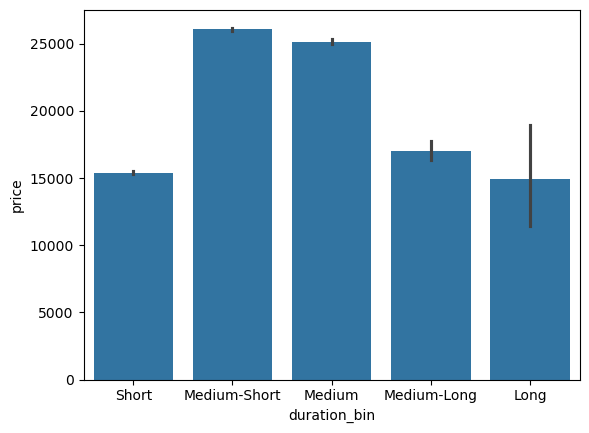

In [38]:
df["duration_bin"] = pd.cut(df["duration"], bins=5, labels=["Short", "Medium-Short", "Medium", "Medium-Long", "Long"])
df.groupby("duration_bin")["price"].mean()
sns.barplot(x="duration_bin", y="price", data=df)


### compagnie aérienne vs prix

C:\Users\Abdelilah\AppData\Local\Temp\ipykernel_18116\3335664960.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('airline')['price'].mean().sort_values(ascending=False)


Text(0, 0.5, 'Prix (USD)')

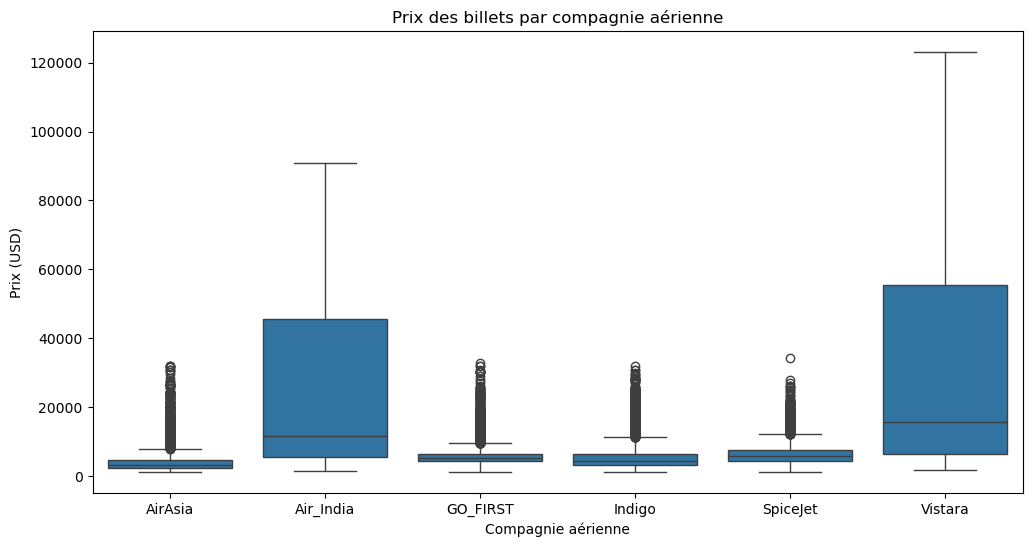

In [ ]:
### compagnie aérienne vs prix
plt.figure(figsize=(12,6))
df.groupby('airline')['price'].mean().sort_values(ascending=False)
sns.boxplot(x='airline', y='price', data=df)
plt.title('Prix des billets par compagnie aérienne')
plt.xlabel('Compagnie aérienne')
plt.ylabel('Prix (USD)')




### nombre d’escales vs prix


Text(0, 0.5, 'Prix (USD)')

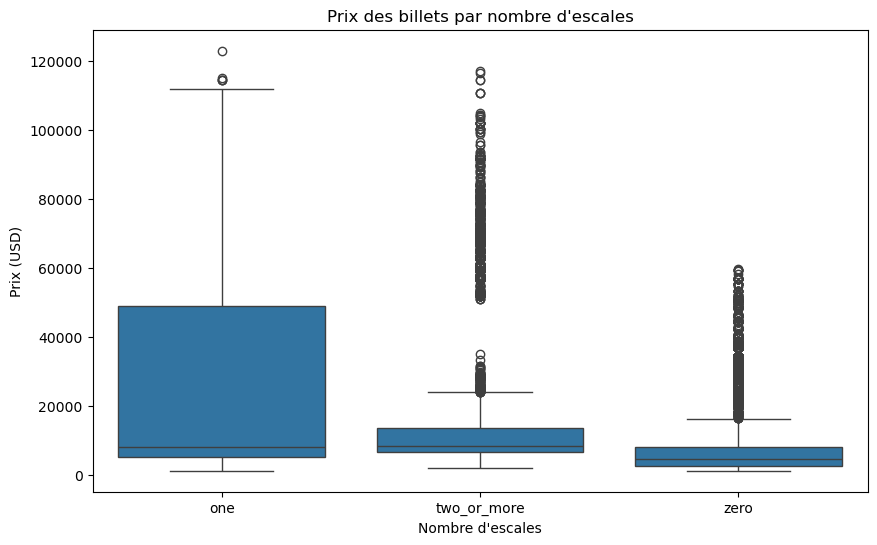

In [46]:
plt.figure(figsize=(10,6))
sns.boxplot(x='stops', y='price', data=df)
plt.title('Prix des billets par nombre d\'escales')
plt.xlabel('Nombre d\'escales')
plt.ylabel('Prix (USD)')


### jours avant vol vs prix


C:\Users\Abdelilah\AppData\Local\Temp\ipykernel_18116\3506446907.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('days_before_flight_bin')['price'].mean()


Text(0, 0.5, 'Prix moyen (USD)')

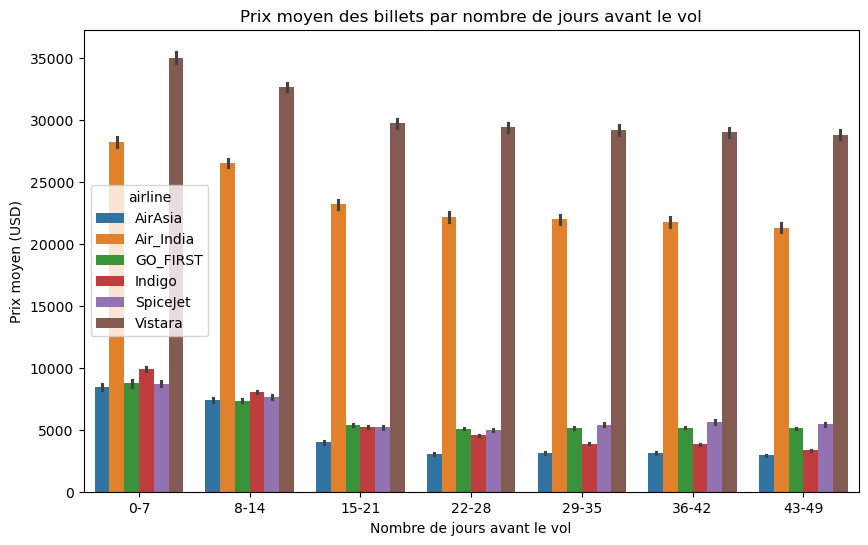

In [59]:
plt.figure(figsize=(10,6))
bins = [0, 7, 14, 21, 28, 35, 42, 49]
labels = ['0-7', '8-14', '15-21', '22-28', '29-35', '36-42', '43-49']
df['days_before_flight_bin'] = pd.cut(df['days_left'], bins=bins, labels=labels)
df.groupby('days_before_flight_bin')['price'].mean()
sns.barplot(x='days_before_flight_bin', y='price', data=df,hue='airline')
plt.title('Prix moyen des billets par nombre de jours avant le vol')
plt.xlabel('Nombre de jours avant le vol')
plt.ylabel('Prix moyen (USD)')
